# Task 07：TRPO 与 PPO——学习与实验入口

## 本 Notebook 的学习边界

PPO 用旧策略与新策略的概率比率控制更新幅度：

$$
r_t(	heta)=rac{\pi_	heta(A_t\mid S_t)}{\pi_{	heta_{old}}(A_t\mid S_t)},
$$

$$
L^{CLIP}=\mathbb{E}_t\left[\min\left(r_tA_t,\operatorname{clip}(r_t,1-\epsilon,1+\epsilon)A_tight)ight].
$$

先理解 actor/critic 与 rollout，再观察 clip 对正负 advantage 的不同作用，最后比较 PPO、one-step Actor-Critic 和 GAE/clip 超参数。


In [1]:
import sys
from pathlib import Path

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt


torch.set_num_threads(1)


# 添加src路径

sys.path.append(
    str(Path("../src").resolve())
)


from network import Actor, Critic
from ppo import PPOAgent
from buffer import RolloutBuffer
from advantage import compute_gae


In [2]:
env = gym.make(
    "CartPole-v1"
)
env.action_space.seed(0)
env.observation_space.seed(0)
env.reset(seed=0)


state_dim = env.observation_space.shape[0]

action_dim = env.action_space.n



actor = Actor(
    state_dim,
    action_dim,
)


critic = Critic(
    state_dim
)



agent = PPOAgent(
    actor,
    critic,
    actor_lr=3e-4,
    critic_lr=1e-3,
    gamma=0.99,
    gae_lambda=0.95,
    clip_eps=0.2,
    entropy_coef=0.01,
    update_epochs=10,
)


buffer = RolloutBuffer()


print(
    "state dim:",
    state_dim
)

print(
    "action dim:",
    action_dim
)


state dim: 4
action dim: 2


In [3]:
def collect_rollout(
    env,
    agent,
    buffer,
    steps,
):

    state, _ = env.reset()

    episode_return = 0

    completed_returns = []


    for _ in range(steps):


        action, log_prob, value = (
            agent.select_action(state)
        )


        next_state, reward, terminated, truncated, _ = (
            env.step(action)
        )


        done = terminated or truncated


        buffer.add(
            state,
            action,
            reward,
            terminated,
            value,
            log_prob,
        )


        episode_return += reward


        state = next_state


        if done:

            completed_returns.append(
                episode_return
            )

            state, _ = env.reset()

            episode_return = 0


    return completed_returns, next_state




num_updates = 40

rollout_steps = 2048


episode_returns = []



for update in range(num_updates):


    buffer.clear()



    returns, next_state = collect_rollout(
        env,
        agent,
        buffer,
        rollout_steps,
    )


    episode_returns.extend(
        returns
    )



    states = torch.tensor(
        np.array(buffer.states),
        dtype=torch.float32
    )


    actions = torch.tensor(
        buffer.actions,
        dtype=torch.long
    )


    old_log_probs = torch.tensor(
        buffer.log_probs,
        dtype=torch.float32
    )


    rewards = torch.tensor(
        buffer.rewards,
        dtype=torch.float32
    )


    values = torch.tensor(
        buffer.values,
        dtype=torch.float32
    )


    dones = torch.tensor(
        buffer.dones,
        dtype=torch.float32
    )



    advantages, target_returns = compute_gae(
        rewards,
        values,
        dones,
        next_value=agent.value(next_state),
        gamma=0.99,
        gae_lambda=0.95,
    )



    # advantage normalization

    advantages = (
        advantages - advantages.mean()
    ) / (
        advantages.std()+1e-8
    )



    agent.update(
        states,
        actions,
        old_log_probs,
        advantages.detach(),
        target_returns.detach(),
    )


    if update % 10 == 0:

        print(
            f"update {update}, "
            f"episodes {len(episode_returns)}"
        )


update 0, episodes 91


update 10, episodes 348


update 20, episodes 402


update 30, episodes 443


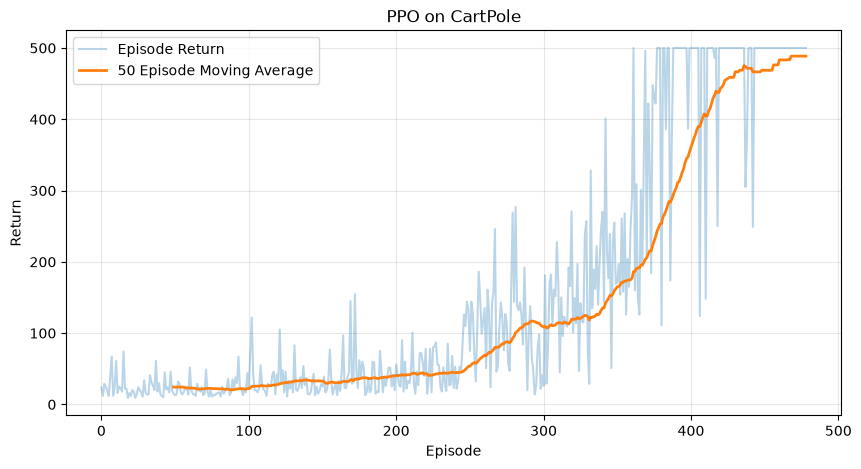

In [4]:
returns = np.array(
    episode_returns
)


window = 50


moving_average = np.convolve(
    returns,
    np.ones(window)/window,
    mode="valid"
)



plt.figure(
    figsize=(10,5)
)


plt.plot(
    returns,
    alpha=0.3,
    label="Episode Return"
)


plt.plot(
    np.arange(
        window-1,
        len(returns)
    ),
    moving_average,
    linewidth=2,
    label="50 Episode Moving Average"
)


plt.xlabel(
    "Episode"
)

plt.ylabel(
    "Return"
)


plt.title(
    "PPO on CartPole"
)


plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


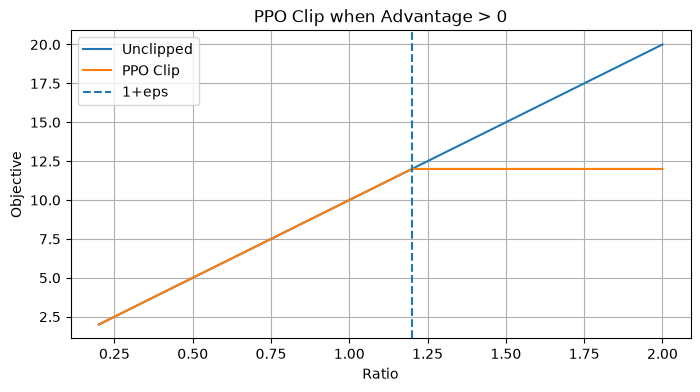

In [5]:
import numpy as np
import matplotlib.pyplot as plt


eps = 0.2


ratios = np.linspace(
    0.2,
    2.0,
    200
)


def ppo_objective(
    ratio,
    advantage
):

    unclipped = (
        ratio
        *
        advantage
    )


    clipped_ratio = np.clip(
        ratio,
        1-eps,
        1+eps
    )


    clipped = (
        clipped_ratio
        *
        advantage
    )


    return np.minimum(
        unclipped,
        clipped
    )

A = 10


loss = ppo_objective(
    ratios,
    A
)


plt.figure(
    figsize=(8,4)
)


plt.plot(
    ratios,
    ratios*A,
    label="Unclipped"
)


plt.plot(
    ratios,
    loss,
    label="PPO Clip"
)


plt.axvline(
    1.2,
    linestyle="--",
    label="1+eps"
)


plt.xlabel(
    "Ratio"
)

plt.ylabel(
    "Objective"
)


plt.title(
    "PPO Clip when Advantage > 0"
)


plt.legend()

plt.grid()

plt.show()


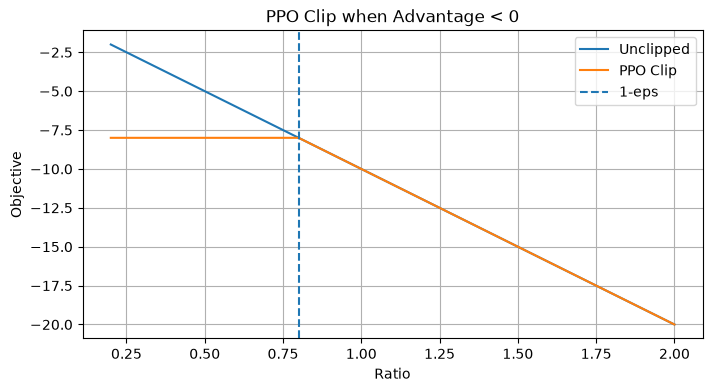

In [6]:
A = -10


loss = ppo_objective(
    ratios,
    A
)


plt.figure(
    figsize=(8,4)
)


plt.plot(
    ratios,
    ratios*A,
    label="Unclipped"
)


plt.plot(
    ratios,
    loss,
    label="PPO Clip"
)


plt.axvline(
    0.8,
    linestyle="--",
    label="1-eps"
)


plt.xlabel(
    "Ratio"
)

plt.ylabel(
    "Objective"
)


plt.title(
    "PPO Clip when Advantage < 0"
)


plt.legend()

plt.grid()

plt.show()


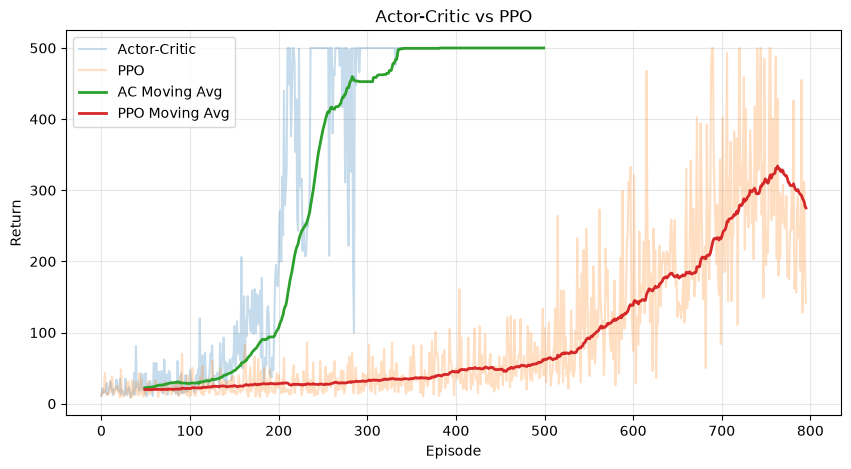

===== Final 100 Episode Performance =====
Actor-Critic: 500.00 ± 0.00
PPO: 290.44 ± 101.78


In [7]:
from ac_baseline import ActorCriticAgent 

import sys
from pathlib import Path

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt


# ============================
# path
# ============================

sys.path.append(
    str(Path("../src").resolve())
)


from network import Actor, Critic
from ppo import PPOAgent
from ac_baseline import ActorCriticAgent
from buffer import RolloutBuffer
from advantage import compute_gae



# ============================
# train PPO
# ============================

def train_ppo(
    seed=0,
    num_updates=40,
    rollout_steps=2048,
):

    torch.manual_seed(seed)
    np.random.seed(seed)


    env = gym.make(
        "CartPole-v1"
    )
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    env.reset(seed=seed)


    state_dim = env.observation_space.shape[0]

    action_dim = env.action_space.n



    actor = Actor(
        state_dim,
        action_dim
    )


    critic = Critic(
        state_dim
    )


    agent = PPOAgent(
        actor,
        critic,
        actor_lr=3e-4,
        critic_lr=1e-3,
        gamma=0.99,
        gae_lambda=0.95,
        clip_eps=0.2,
        entropy_coef=0.01,
        update_epochs=10,
        minibatch_size=2048,
    )


    buffer = RolloutBuffer()


    episode_returns = []


    for update in range(num_updates):


        buffer.clear()


        state, _ = env.reset()

        episode_return = 0



        for _ in range(rollout_steps):


            action, log_prob, value = (
                agent.select_action(state)
            )


            next_state, reward, terminated, truncated, _ = (
                env.step(action)
            )


            done = terminated or truncated



            buffer.add(
                state,
                action,
                reward,
                terminated,
                value,
                log_prob,
            )


            episode_return += reward

            state = next_state



            if done:

                episode_returns.append(
                    episode_return
                )

                state, _ = env.reset()

                episode_return = 0



        states = torch.tensor(
            np.array(buffer.states),
            dtype=torch.float32
        )


        actions = torch.tensor(
            buffer.actions,
            dtype=torch.long
        )


        old_log_probs = torch.tensor(
            buffer.log_probs,
            dtype=torch.float32
        )


        rewards = torch.tensor(
            buffer.rewards,
            dtype=torch.float32
        )


        values = torch.tensor(
            buffer.values,
            dtype=torch.float32
        )


        dones = torch.tensor(
            buffer.dones,
            dtype=torch.float32
        )


        advantages, returns = compute_gae(
            rewards,
            values,
            dones,
            next_value=agent.value(next_state),
            gamma=0.99,
            gae_lambda=0.95,
        )


        advantages = (
            advantages - advantages.mean()
        ) / (
            advantages.std()+1e-8
        )


        agent.update(
            states,
            actions,
            old_log_probs,
            advantages.detach(),
            returns.detach(),
        )


    env.close()

    return np.array(
        episode_returns
    )



# ============================
# train Actor-Critic
# ============================

def train_ac(
    seed=0,
    episodes=500,
):

    torch.manual_seed(seed)
    np.random.seed(seed)


    env = gym.make(
        "CartPole-v1"
    )


    state_dim = env.observation_space.shape[0]

    action_dim = env.action_space.n



    actor = Actor(
        state_dim,
        action_dim
    )


    critic = Critic(
        state_dim
    )



    agent = ActorCriticAgent(
        actor,
        critic,
        actor_lr=1e-4,
        critic_lr=5e-4,
        gamma=0.99,
    )



    episode_returns = []



    for episode in range(episodes):


        state, _ = env.reset()


        done = False


        rewards = []



        while not done:


            action = agent.select_action(state)


            next_state, reward, terminated, truncated, _ = (
                env.step(action)
            )


            done = terminated or truncated


            agent.update(
                state,
                action,
                reward,
                next_state,
                terminated,
            )


            rewards.append(
                reward
            )


            state = next_state





        episode_returns.append(
            sum(rewards)
        )



    env.close()


    return np.array(
        episode_returns
    )



# ============================
# Run experiment
# ============================


ac_returns = train_ac(
    seed=0
)


ppo_returns = train_ppo(
    seed=0
)



# ============================
# Plot
# ============================


window = 50


ac_ma = np.convolve(
    ac_returns,
    np.ones(window)/window,
    mode="valid"
)


ppo_ma = np.convolve(
    ppo_returns,
    np.ones(window)/window,
    mode="valid"
)



plt.figure(
    figsize=(10,5)
)


plt.plot(
    ac_returns,
    alpha=0.25,
    label="Actor-Critic"
)


plt.plot(
    ppo_returns,
    alpha=0.25,
    label="PPO"
)



plt.plot(
    np.arange(
        window-1,
        len(ac_returns)
    ),
    ac_ma,
    linewidth=2,
    label="AC Moving Avg"
)



plt.plot(
    np.arange(
        window-1,
        len(ppo_returns)
    ),
    ppo_ma,
    linewidth=2,
    label="PPO Moving Avg"
)



plt.xlabel(
    "Episode"
)


plt.ylabel(
    "Return"
)


plt.title(
    "Actor-Critic vs PPO"
)


plt.legend()

plt.grid(
    alpha=0.3
)


plt.show()



# ============================
# final statistics
# ============================

print(
    "===== Final 100 Episode Performance ====="
)


print(
    f"Actor-Critic: "
    f"{ac_returns[-100:].mean():.2f}"
    f" ± "
    f"{ac_returns[-100:].std():.2f}"
)


print(
    f"PPO: "
    f"{ppo_returns[-100:].mean():.2f}"
    f" ± "
    f"{ppo_returns[-100:].std():.2f}"
)


Training PPO eps=0.05


Training PPO eps=0.2


Training PPO eps=0.5


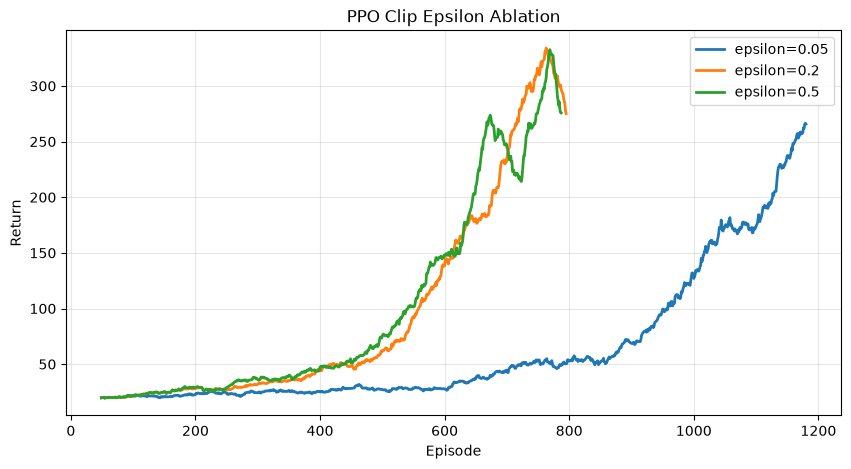

===== Final 100 Episode Performance =====
epsilon=0.05: 235.45 ± 94.33
epsilon=0.2: 290.44 ± 101.78
epsilon=0.5: 270.05 ± 117.45


In [8]:
def train_ppo_clip(
    clip_eps,
    seed=0,
    num_updates=40,
    rollout_steps=2048,
):

    torch.manual_seed(seed)
    np.random.seed(seed)


    env = gym.make(
        "CartPole-v1"
    )
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    env.reset(seed=seed)


    state_dim = env.observation_space.shape[0]

    action_dim = env.action_space.n



    actor = Actor(
        state_dim,
        action_dim
    )


    critic = Critic(
        state_dim
    )



    agent = PPOAgent(
        actor,
        critic,
        actor_lr=3e-4,
        critic_lr=1e-3,
        gamma=0.99,
        gae_lambda=0.95,
        clip_eps=clip_eps,
        entropy_coef=0.01,
        update_epochs=10,
        minibatch_size=2048,
    )



    buffer = RolloutBuffer()


    episode_returns = []



    for update in range(num_updates):


        buffer.clear()


        state, _ = env.reset()

        episode_return = 0



        for _ in range(rollout_steps):


            action, log_prob, value = (
                agent.select_action(state)
            )


            next_state, reward, terminated, truncated, _ = (
                env.step(action)
            )


            done = terminated or truncated



            buffer.add(
                state,
                action,
                reward,
                terminated,
                value,
                log_prob,
            )


            episode_return += reward

            state = next_state



            if done:

                episode_returns.append(
                    episode_return
                )

                state, _ = env.reset()

                episode_return = 0



        states = torch.tensor(
            np.array(buffer.states),
            dtype=torch.float32
        )


        actions = torch.tensor(
            buffer.actions,
            dtype=torch.long
        )


        old_log_probs = torch.tensor(
            buffer.log_probs,
            dtype=torch.float32
        )


        rewards = torch.tensor(
            buffer.rewards,
            dtype=torch.float32
        )


        values = torch.tensor(
            buffer.values,
            dtype=torch.float32
        )


        dones = torch.tensor(
            buffer.dones,
            dtype=torch.float32
        )



        advantages, returns = compute_gae(
            rewards,
            values,
            dones,
            next_value=agent.value(next_state),
            gamma=0.99,
            gae_lambda=0.95,
        )



        advantages = (
            advantages - advantages.mean()
        ) / (
            advantages.std()+1e-8
        )



        agent.update(
            states,
            actions,
            old_log_probs,
            advantages.detach(),
            returns.detach(),
        )



    env.close()


    return np.array(
        episode_returns
    )




# ==============================
# Run different epsilon
# ==============================


eps_list = [
    0.05,
    0.2,
    0.5,
]


results = {}



for eps in eps_list:

    print(
        f"Training PPO eps={eps}"
    )


    results[eps] = train_ppo_clip(
        clip_eps=eps,
        seed=0,
    )



# ==============================
# Plot
# ==============================


plt.figure(
    figsize=(10,5)
)



window = 50



for eps, returns in results.items():


    ma = np.convolve(
        returns,
        np.ones(window)/window,
        mode="valid"
    )


    plt.plot(
        np.arange(
            window-1,
            len(returns)
        ),
        ma,
        linewidth=2,
        label=f"epsilon={eps}"
    )



plt.xlabel(
    "Episode"
)


plt.ylabel(
    "Return"
)


plt.title(
    "PPO Clip Epsilon Ablation"
)


plt.legend()

plt.grid(
    alpha=0.3
)


plt.show()



# ==============================
# Final statistics
# ==============================


print(
    "===== Final 100 Episode Performance ====="
)


for eps, returns in results.items():

    print(
        f"epsilon={eps}: "
        f"{returns[-100:].mean():.2f}"
        f" ± "
        f"{returns[-100:].std():.2f}"
    )


Training PPO lambda=0.0


Training PPO lambda=0.95


Training PPO lambda=1.0


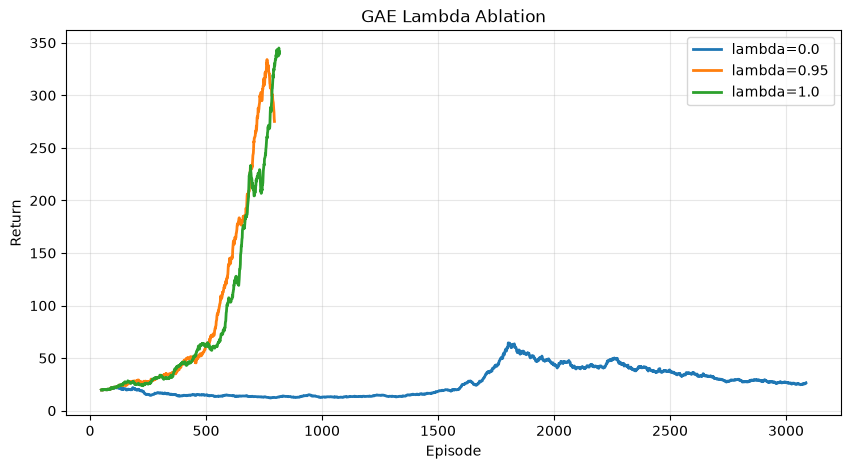

===== Final 100 Episode Performance =====
lambda=0.0: 26.22 ± 8.27
lambda=0.95: 290.44 ± 101.78
lambda=1.0: 305.68 ± 120.30


In [9]:
def train_ppo_lambda(
    gae_lambda,
    seed=0,
    num_updates=40,
    rollout_steps=2048,
):

    torch.manual_seed(seed)
    np.random.seed(seed)


    env = gym.make(
        "CartPole-v1"
    )
    env.action_space.seed(seed)
    env.observation_space.seed(seed)
    env.reset(seed=seed)


    state_dim = env.observation_space.shape[0]

    action_dim = env.action_space.n



    actor = Actor(
        state_dim,
        action_dim
    )


    critic = Critic(
        state_dim
    )



    agent = PPOAgent(
        actor,
        critic,
        actor_lr=3e-4,
        critic_lr=1e-3,
        gamma=0.99,
        gae_lambda=gae_lambda,
        clip_eps=0.2,
        entropy_coef=0.01,
        update_epochs=10,
        minibatch_size=2048,
    )


    buffer = RolloutBuffer()


    episode_returns = []



    for update in range(num_updates):


        buffer.clear()


        state, _ = env.reset()

        episode_return = 0



        for _ in range(rollout_steps):


            action, log_prob, value = (
                agent.select_action(state)
            )


            next_state, reward, terminated, truncated, _ = (
                env.step(action)
            )


            done = terminated or truncated



            buffer.add(
                state,
                action,
                reward,
                terminated,
                value,
                log_prob,
            )


            episode_return += reward


            state = next_state



            if done:

                episode_returns.append(
                    episode_return
                )


                state, _ = env.reset()

                episode_return = 0



        states = torch.tensor(
            np.array(buffer.states),
            dtype=torch.float32
        )


        actions = torch.tensor(
            buffer.actions,
            dtype=torch.long
        )


        old_log_probs = torch.tensor(
            buffer.log_probs,
            dtype=torch.float32
        )


        rewards = torch.tensor(
            buffer.rewards,
            dtype=torch.float32
        )


        values = torch.tensor(
            buffer.values,
            dtype=torch.float32
        )


        dones = torch.tensor(
            buffer.dones,
            dtype=torch.float32
        )



        advantages, returns = compute_gae(
            rewards,
            values,
            dones,
            next_value=agent.value(next_state),
            gamma=0.99,
            gae_lambda=gae_lambda,
        )



        # advantage normalization

        advantages = (
            advantages - advantages.mean()
        ) / (
            advantages.std()+1e-8
        )



        agent.update(
            states,
            actions,
            old_log_probs,
            advantages.detach(),
            returns.detach(),
        )



    env.close()


    return np.array(
        episode_returns
    )





# =========================
# Run experiments
# =========================


lambda_list = [
    0.0,
    0.95,
    1.0,
]


results = {}



for lam in lambda_list:

    print(
        f"Training PPO lambda={lam}"
    )


    results[lam] = train_ppo_lambda(
        gae_lambda=lam,
        seed=0,
    )





# =========================
# Plot
# =========================


plt.figure(
    figsize=(10,5)
)


window = 50



for lam, returns in results.items():


    ma = np.convolve(
        returns,
        np.ones(window)/window,
        mode="valid"
    )


    plt.plot(
        np.arange(
            window-1,
            len(returns)
        ),
        ma,
        linewidth=2,
        label=f"lambda={lam}"
    )



plt.xlabel(
    "Episode"
)


plt.ylabel(
    "Return"
)


plt.title(
    "GAE Lambda Ablation"
)


plt.legend()

plt.grid(
    alpha=0.3
)


plt.show()





# =========================
# Final statistics
# =========================


print(
    "===== Final 100 Episode Performance ====="
)


for lam, returns in results.items():

    print(
        f"lambda={lam}: "
        f"{returns[-100:].mean():.2f}"
        f" ± "
        f"{returns[-100:].std():.2f}"
    )


Update   0 | Episodes   49 | Return   20.05 | KL 0.007895 | Accepted True | LineSearch 0
Update  10 | Episodes  183 | Return  262.00 | KL 0.008192 | Accepted True | LineSearch 0
Update  20 | Episodes  214 | Return  292.45 | KL 0.008248 | Accepted True | LineSearch 0
Update  30 | Episodes  242 | Return  373.80 | KL 0.007506 | Accepted True | LineSearch 0
Update  40 | Episodes  275 | Return  308.50 | KL 0.005812 | Accepted True | LineSearch 0
Update  50 | Episodes  302 | Return  385.85 | KL 0.005675 | Accepted True | LineSearch 0
Update  60 | Episodes  333 | Return  353.10 | KL 0.008232 | Accepted True | LineSearch 0
Update  70 | Episodes  357 | Return  447.85 | KL 0.006335 | Accepted True | LineSearch 0
Update  80 | Episodes  382 | Return  406.20 | KL 0.007236 | Accepted True | LineSearch 0
Update  90 | Episodes  408 | Return  401.35 | KL 0.004426 | Accepted True | LineSearch 0


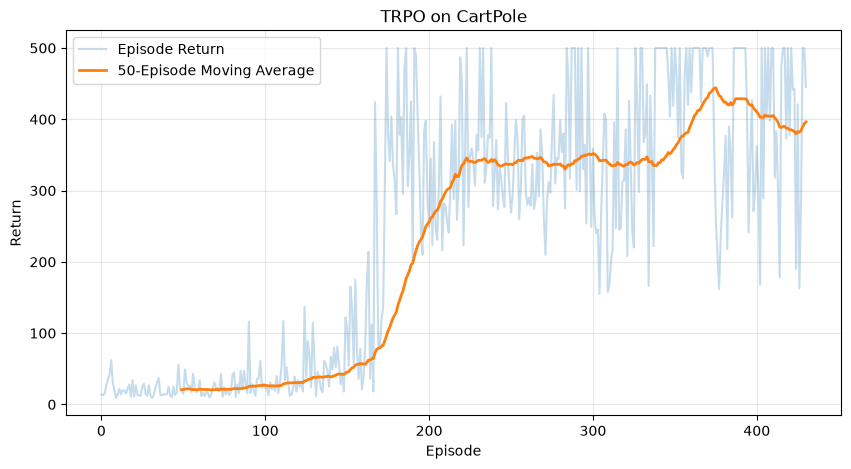

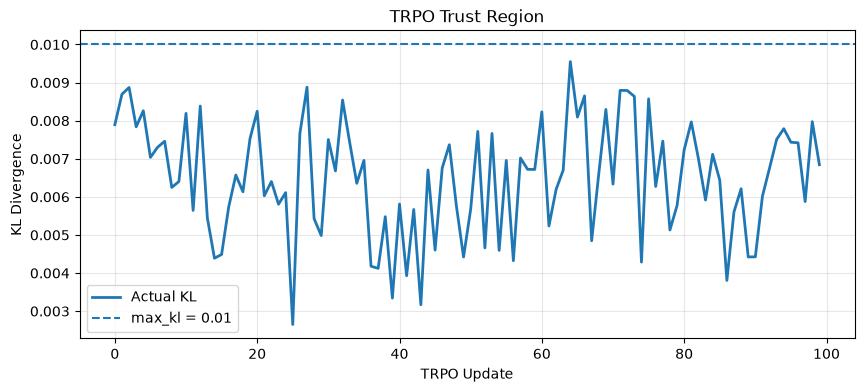


===== TRPO Final Performance =====
Final 100 Episodes: 410.19 ± 104.44
Mean KL: 0.006498
Max KL: 0.009551
Line Search Acceptance Rate: 100.00%


In [1]:
import sys
from pathlib import Path

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Path
# ============================================================

sys.path.append(
    str(Path("../src").resolve())
)


from network import Actor, Critic
from trpo import TRPOAgent
from buffer import RolloutBuffer
from advantage import compute_gae


# ============================================================
# Reproducibility
# ============================================================

SEED = 0

torch.manual_seed(SEED)
np.random.seed(SEED)


# ============================================================
# Environment
# ============================================================

env = gym.make(
    "CartPole-v1"
)

env.action_space.seed(SEED)

state, _ = env.reset(
    seed=SEED
)


state_dim = env.observation_space.shape[0]
action_dim = env.action_space.n


# ============================================================
# Actor / Critic
# ============================================================

actor = Actor(
    state_dim=state_dim,
    action_dim=action_dim,
    hidden_dim=64,
)


critic = Critic(
    state_dim=state_dim,
    hidden_dim=64,
)


# ============================================================
# TRPO Agent
# ============================================================

agent = TRPOAgent(
    actor=actor,
    critic=critic,

    critic_lr=1e-3,

    # Trust Region
    max_kl=0.01,

    # Natural Gradient / CG
    damping=0.1,
    cg_iters=10,

    # Line Search
    backtrack_iters=10,
    backtrack_coeff=0.8,

    # Critic
    critic_updates=10,
)


buffer = RolloutBuffer()


# ============================================================
# Training Config
# ============================================================

num_updates = 100

rollout_steps = 1024

gamma = 0.99
gae_lambda = 0.95


episode_returns = []

kl_history = []
accepted_history = []
line_search_history = []


episode_return = 0.0

last_done = False


# ============================================================
# Training
# ============================================================

for update in range(num_updates):

    buffer.clear()


    # --------------------------------------------------------
    # 1. Collect rollout
    # --------------------------------------------------------

    for _ in range(rollout_steps):

        action, log_prob, value = (
            agent.select_action(state)
        )


        next_state, reward, terminated, truncated, _ = (
            env.step(action)
        )


        done = (
            terminated
            or truncated
        )


        buffer.add(
            state=state,
            action=action,
            reward=reward,
            done=done,
            value=value,
            log_prob=log_prob,
        )


        episode_return += reward


        state = next_state

        last_done = done


        if done:

            episode_returns.append(
                episode_return
            )

            episode_return = 0.0


            state, _ = env.reset()


    # --------------------------------------------------------
    # 2. Bootstrap value at rollout boundary
    # --------------------------------------------------------

    if last_done:

        last_value = 0.0

    else:

        last_value = agent.get_value(
            state
        )


    # --------------------------------------------------------
    # 3. Buffer -> Tensor
    # --------------------------------------------------------

    states = torch.tensor(
        np.array(buffer.states),
        dtype=torch.float32,
    )


    actions = torch.tensor(
        buffer.actions,
        dtype=torch.long,
    )


    old_log_probs = torch.tensor(
        buffer.log_probs,
        dtype=torch.float32,
    )


    rewards = torch.tensor(
        buffer.rewards,
        dtype=torch.float32,
    )


    values = torch.tensor(
        buffer.values,
        dtype=torch.float32,
    )


    dones = torch.tensor(
        buffer.dones,
        dtype=torch.float32,
    )


    # --------------------------------------------------------
    # 4. GAE
    # --------------------------------------------------------

    advantages, returns = compute_gae(
        rewards=rewards,
        values=values,
        dones=dones,
        last_value=last_value,
        gamma=gamma,
        gae_lambda=gae_lambda,
    )


    # --------------------------------------------------------
    # 5. TRPO Update
    # --------------------------------------------------------

    info = agent.update(
        states=states,
        actions=actions,
        old_log_probs=old_log_probs,
        advantages=advantages.detach(),
        returns=returns.detach(),
    )


    kl_history.append(
        info["kl"]
    )

    accepted_history.append(
        float(info["accepted"])
    )

    line_search_history.append(
        info["line_search_step"]
    )


    # --------------------------------------------------------
    # 6. Logging
    # --------------------------------------------------------

    if update % 10 == 0:

        if len(episode_returns) >= 20:

            recent_return = np.mean(
                episode_returns[-20:]
            )

        elif len(episode_returns) > 0:

            recent_return = np.mean(
                episode_returns
            )

        else:

            recent_return = 0.0


        print(
            f"Update {update:3d} | "
            f"Episodes {len(episode_returns):4d} | "
            f"Return {recent_return:7.2f} | "
            f"KL {info['kl']:.6f} | "
            f"Accepted {info['accepted']} | "
            f"LineSearch {info['line_search_step']}"
        )


env.close()


# ============================================================
# Return Curve
# ============================================================

returns_array = np.asarray(
    episode_returns,
    dtype=np.float32,
)


window = 50


moving_average = np.convolve(
    returns_array,
    np.ones(window) / window,
    mode="valid",
)


plt.figure(
    figsize=(10, 5)
)


plt.plot(
    returns_array,
    alpha=0.25,
    label="Episode Return",
)


plt.plot(
    np.arange(
        window - 1,
        len(returns_array),
    ),
    moving_average,
    linewidth=2,
    label="50-Episode Moving Average",
)


plt.xlabel("Episode")
plt.ylabel("Return")

plt.title(
    "TRPO on CartPole"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# KL Curve
# ============================================================

plt.figure(
    figsize=(10, 4)
)


plt.plot(
    kl_history,
    linewidth=2,
    label="Actual KL",
)


plt.axhline(
    0.01,
    linestyle="--",
    label="max_kl = 0.01",
)


plt.xlabel("TRPO Update")
plt.ylabel("KL Divergence")

plt.title(
    "TRPO Trust Region"
)

plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# Statistics
# ============================================================

print(
    "\n===== TRPO Final Performance ====="
)


print(
    f"Final 100 Episodes: "
    f"{returns_array[-100:].mean():.2f} "
    f"± "
    f"{returns_array[-100:].std():.2f}"
)


print(
    f"Mean KL: "
    f"{np.mean(kl_history):.6f}"
)


print(
    f"Max KL: "
    f"{np.max(kl_history):.6f}"
)


print(
    f"Line Search Acceptance Rate: "
    f"{np.mean(accepted_history) * 100:.2f}%"
)

In [ ]:
import sys
from pathlib import Path

import gymnasium as gym
import torch
import numpy as np
import matplotlib.pyplot as plt


# ============================================================
# Path
# ============================================================

sys.path.append(
    str(Path("../src").resolve())
)


from network import Actor, Critic
from trpo import TRPOAgent
from ppo import PPOAgent
from buffer import RolloutBuffer
from advantage import compute_gae


# ============================================================
# Config
# ============================================================

SEED = 0

NUM_UPDATES = 100
ROLLOUT_STEPS = 1024

GAMMA = 0.99
GAE_LAMBDA = 0.95

WINDOW = 50


# ============================================================
# Utility
# ============================================================

def compute_mean_kl(
    old_probs,
    new_probs,
):

    old_probs = old_probs.clamp_min(1e-8)
    new_probs = new_probs.clamp_min(1e-8)

    kl = (
        old_probs
        *
        (
            torch.log(old_probs)
            -
            torch.log(new_probs)
        )
    ).sum(dim=-1)

    return kl.mean().item()


# ============================================================
# Train TRPO
# ============================================================

def train_trpo(
    seed=0,
):

    torch.manual_seed(seed)
    np.random.seed(seed)


    env = gym.make(
        "CartPole-v1"
    )

    env.action_space.seed(seed)

    state, _ = env.reset(
        seed=seed
    )


    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n


    actor = Actor(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dim=64,
    )

    critic = Critic(
        state_dim=state_dim,
        hidden_dim=64,
    )


    agent = TRPOAgent(
        actor=actor,
        critic=critic,

        critic_lr=1e-3,

        max_kl=0.01,

        damping=0.1,
        cg_iters=10,

        backtrack_iters=10,
        backtrack_coeff=0.8,

        critic_updates=10,
    )


    buffer = RolloutBuffer()


    episode_returns = []
    episode_steps = []

    kl_history = []


    episode_return = 0.0

    total_steps = 0
    last_done = False


    for update in range(
        NUM_UPDATES
    ):

        buffer.clear()


        # ----------------------------------------------------
        # Rollout
        # ----------------------------------------------------

        for _ in range(
            ROLLOUT_STEPS
        ):

            action, log_prob, value = (
                agent.select_action(state)
            )


            next_state, reward, terminated, truncated, _ = (
                env.step(action)
            )


            done = (
                terminated
                or truncated
            )


            buffer.add(
                state=state,
                action=action,
                reward=reward,
                done=done,
                value=value,
                log_prob=log_prob,
            )


            total_steps += 1

            episode_return += reward


            state = next_state

            last_done = done


            if done:

                episode_returns.append(
                    episode_return
                )

                episode_steps.append(
                    total_steps
                )

                episode_return = 0.0

                state, _ = env.reset()


        # ----------------------------------------------------
        # Bootstrap
        # ----------------------------------------------------

        if last_done:

            last_value = 0.0

        else:

            last_value = agent.get_value(
                state
            )


        # ----------------------------------------------------
        # Tensor
        # ----------------------------------------------------

        states = torch.tensor(
            np.array(buffer.states),
            dtype=torch.float32,
        )

        actions = torch.tensor(
            buffer.actions,
            dtype=torch.long,
        )

        old_log_probs = torch.tensor(
            buffer.log_probs,
            dtype=torch.float32,
        )

        rewards = torch.tensor(
            buffer.rewards,
            dtype=torch.float32,
        )

        values = torch.tensor(
            buffer.values,
            dtype=torch.float32,
        )

        dones = torch.tensor(
            buffer.dones,
            dtype=torch.float32,
        )


        # ----------------------------------------------------
        # GAE
        # ----------------------------------------------------

        advantages, returns = compute_gae(
            rewards=rewards,
            values=values,
            dones=dones,
            last_value=last_value,
            gamma=GAMMA,
            gae_lambda=GAE_LAMBDA,
        )


        # ----------------------------------------------------
        # TRPO Update
        # ----------------------------------------------------

        info = agent.update(
            states=states,
            actions=actions,
            old_log_probs=old_log_probs,
            advantages=advantages.detach(),
            returns=returns.detach(),
        )


        kl_history.append(
            info["kl"]
        )


    env.close()


    return {
        "returns": np.asarray(
            episode_returns,
            dtype=np.float32,
        ),

        "steps": np.asarray(
            episode_steps,
            dtype=np.int64,
        ),

        "kl": np.asarray(
            kl_history,
            dtype=np.float32,
        ),
    }


# ============================================================
# Train PPO
# ============================================================

def train_ppo(
    seed=0,
):

    torch.manual_seed(seed)
    np.random.seed(seed)


    env = gym.make(
        "CartPole-v1"
    )

    env.action_space.seed(seed)

    state, _ = env.reset(
        seed=seed
    )


    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n


    actor = Actor(
        state_dim=state_dim,
        action_dim=action_dim,
        hidden_dim=64,
    )

    critic = Critic(
        state_dim=state_dim,
        hidden_dim=64,
    )


    agent = PPOAgent(
        actor=actor,
        critic=critic,

        actor_lr=3e-4,
        critic_lr=1e-3,

        gamma=GAMMA,
        gae_lambda=GAE_LAMBDA,

        clip_eps=0.2,

        entropy_coef=0.01,

        update_epochs=10,
    )


    buffer = RolloutBuffer()


    episode_returns = []
    episode_steps = []

    kl_history = []


    episode_return = 0.0

    total_steps = 0
    last_done = False


    for update in range(
        NUM_UPDATES
    ):

        buffer.clear()


        # ----------------------------------------------------
        # Rollout
        # ----------------------------------------------------

        for _ in range(
            ROLLOUT_STEPS
        ):

            action, log_prob, value = (
                agent.select_action(state)
            )


            next_state, reward, terminated, truncated, _ = (
                env.step(action)
            )


            done = (
                terminated
                or truncated
            )


            buffer.add(
                state=state,
                action=action,
                reward=reward,
                done=done,
                value=value,
                log_prob=log_prob,
            )


            total_steps += 1

            episode_return += reward


            state = next_state

            last_done = done


            if done:

                episode_returns.append(
                    episode_return
                )

                episode_steps.append(
                    total_steps
                )

                episode_return = 0.0

                state, _ = env.reset()


        # ----------------------------------------------------
        # Bootstrap
        # ----------------------------------------------------

        if last_done:

            last_value = 0.0

        else:

            state_tensor = torch.tensor(
                state,
                dtype=torch.float32,
            ).unsqueeze(0)


            with torch.no_grad():

                last_value = (
                    agent.critic(
                        state_tensor
                    )
                    .item()
                )


        # ----------------------------------------------------
        # Tensor
        # ----------------------------------------------------

        states = torch.tensor(
            np.array(buffer.states),
            dtype=torch.float32,
        )

        actions = torch.tensor(
            buffer.actions,
            dtype=torch.long,
        )

        old_log_probs = torch.tensor(
            buffer.log_probs,
            dtype=torch.float32,
        )

        rewards = torch.tensor(
            buffer.rewards,
            dtype=torch.float32,
        )

        values = torch.tensor(
            buffer.values,
            dtype=torch.float32,
        )

        dones = torch.tensor(
            buffer.dones,
            dtype=torch.float32,
        )


        # ----------------------------------------------------
        # GAE
        # ----------------------------------------------------

        advantages, returns = compute_gae(
            rewards=rewards,
            values=values,
            dones=dones,
            last_value=last_value,
            gamma=GAMMA,
            gae_lambda=GAE_LAMBDA,
        )


        advantages = (
            advantages
            -
            advantages.mean()
        ) / (
            advantages.std()
            +
            1e-8
        )


        # ----------------------------------------------------
        # 保存update之前的policy
        # 用于计算真实KL
        # ----------------------------------------------------

        with torch.no_grad():

            old_probs = (
                actor(states)
                .probs
                .detach()
            )


        # ----------------------------------------------------
        # PPO Update
        # ----------------------------------------------------

        agent.update(
            states=states,
            actions=actions,
            old_log_probs=old_log_probs,
            advantages=advantages.detach(),
            returns=returns.detach(),
        )


        # ----------------------------------------------------
        # PPO update之后的KL
        # ----------------------------------------------------

        with torch.no_grad():

            new_probs = (
                actor(states)
                .probs
                .detach()
            )


        mean_kl = compute_mean_kl(
            old_probs,
            new_probs,
        )


        kl_history.append(
            mean_kl
        )


    env.close()


    return {
        "returns": np.asarray(
            episode_returns,
            dtype=np.float32,
        ),

        "steps": np.asarray(
            episode_steps,
            dtype=np.int64,
        ),

        "kl": np.asarray(
            kl_history,
            dtype=np.float32,
        ),
    }


# ============================================================
# Run
# ============================================================

print("Training TRPO...")

trpo_result = train_trpo(
    seed=SEED
)


print("Training PPO...")

ppo_result = train_ppo(
    seed=SEED
)


# ============================================================
# Moving Average
# ============================================================

trpo_returns = trpo_result[
    "returns"
]

ppo_returns = ppo_result[
    "returns"
]


trpo_ma = np.convolve(
    trpo_returns,
    np.ones(WINDOW) / WINDOW,
    mode="valid",
)


ppo_ma = np.convolve(
    ppo_returns,
    np.ones(WINDOW) / WINDOW,
    mode="valid",
)


trpo_ma_steps = trpo_result[
    "steps"
][
    WINDOW - 1:
]


ppo_ma_steps = ppo_result[
    "steps"
][
    WINDOW - 1:
]


# ============================================================
# Plot 1:
# Return vs Environment Steps
# ============================================================

plt.figure(
    figsize=(10, 5)
)


plt.plot(
    trpo_ma_steps,
    trpo_ma,
    linewidth=2,
    label="TRPO",
)


plt.plot(
    ppo_ma_steps,
    ppo_ma,
    linewidth=2,
    label="PPO",
)


plt.xlabel(
    "Environment Steps"
)

plt.ylabel(
    "50-Episode Moving Average Return"
)


plt.title(
    "TRPO vs PPO on CartPole"
)


plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# Plot 2:
# Policy KL per Update
# ============================================================

plt.figure(
    figsize=(10, 4)
)


plt.plot(
    trpo_result["kl"],
    linewidth=2,
    label="TRPO KL",
)


plt.plot(
    ppo_result["kl"],
    linewidth=2,
    label="PPO KL",
)


plt.axhline(
    0.01,
    linestyle="--",
    label="TRPO max_kl = 0.01",
)


plt.xlabel(
    "Policy Update"
)

plt.ylabel(
    "KL Divergence"
)


plt.title(
    "Policy Change: TRPO vs PPO"
)


plt.legend()

plt.grid(
    alpha=0.3
)

plt.show()


# ============================================================
# Statistics
# ============================================================

print(
    "\n===== Final 100 Episode Performance ====="
)


print(
    f"TRPO: "
    f"{trpo_returns[-100:].mean():.2f} "
    f"± "
    f"{trpo_returns[-100:].std():.2f}"
)


print(
    f"PPO : "
    f"{ppo_returns[-100:].mean():.2f} "
    f"± "
    f"{ppo_returns[-100:].std():.2f}"
)


print(
    "\n===== Policy KL ====="
)


print(
    f"TRPO Mean KL: "
    f"{trpo_result['kl'].mean():.6f}"
)


print(
    f"TRPO Max KL : "
    f"{trpo_result['kl'].max():.6f}"
)


print(
    f"PPO Mean KL : "
    f"{ppo_result['kl'].mean():.6f}"
)


print(
    f"PPO Max KL  : "
    f"{ppo_result['kl'].max():.6f}"
)

## 实验结论与提交要求

运行完本 Notebook 后，不要只保留图。请在对应 `notes/` 中记录随机种子、环境版本、关键超参数、最终指标、曲线文件和一个失败现象。结论必须区分“代码运行成功”和“算法表现更好”：前者由自检确认，后者需要多 seed 或控制变量实验支持。

提交前从仓库根目录运行：

```bash
python eval/run.py
```
